In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [18]:
 def prepare_data_for_ks_test_single(file, skip, teff_min, teff_max, rad_min, rad_max):
    df_combined = pd.DataFrame()
    #plt.figure(figsize=(10, 6))

    df = pd.read_csv(file, skiprows=skip)

    if 'Stellar Eff Temp (K)' in df.columns:
        df.rename(columns={'Stellar Eff Temp (K)': 'st_teff'}, inplace=True)
    if 'Planet Radius (R_Earth)' in df.columns:
        df.rename(columns={'Planet Radius (R_Earth)': 'pl_rade'}, inplace=True)
    #print(df.columns)

    df = df.dropna(subset=['st_teff', 'pl_rade'])
    df = df[(df['st_teff'] < teff_max) & (df['st_teff'] > teff_min)]
    df = df[(df['pl_rade'] < rad_max) & (df['pl_rade'] > rad_min)]

    if 'tfopwg_disp' in df.columns:
        df = df[df['tfopwg_disp'] != 'FP']

    df_combined = pd.concat([df_combined, df], ignore_index=True)

    plt.scatter(df['pl_rade'], df['st_teff'], alpha=0.5, label=file)
    if 'pl_name' in df.columns:
        for i, txt in enumerate(df['pl_name']):
            plt.annotate(txt, (df['pl_rade'].iloc[i], df['st_teff'].iloc[i]), fontsize=8, alpha=0.7)

    try:
        df_combined = df_combined[df_combined['pl_name'].isnull() | ~df_combined[df_combined['pl_name'].notnull()].duplicated(subset='pl_name', keep='first')]
    except KeyError as e:
        print(f"KeyError: {e}")

    df_combined.rename(columns={'tid': 'tic_id', 'TIC ID': 'tic_id'}, inplace=True)

    plt.title('Planetary Radius vs Stellar Effective Temperature')
    plt.ylabel('Stellar Effective Temperature (K)')
    plt.xlabel('Planetary Radius (Earth Radii)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return df_combined[['pl_rade', 'st_teff']], len(df_combined)

def perform_ks_test(file1, skip1, file2, skip2, teff_min1=3000, teff_max1=3200, teff_min2=3200, teff_max2=3400, rad_min1=0, rad_max1=10, rad_min2=0, rad_max2=10):
   

    data_for_ks_test_1, file_1_len = prepare_data_for_ks_test_single(file1, skip1, teff_min1, teff_max1, rad_min1, rad_max1)
    data_for_ks_test_2, file_2_len = prepare_data_for_ks_test_single(file2, skip2 ,teff_min2, teff_max2, rad_min2, rad_max2)

    from scipy.stats import ks_2samp

    #print('≤ 0 as indicating no agreement and 0.01–0.20 as none to slight, 0.21–0.40 as fair, 0.41– 0.60 as moderate, 0.61–0.80 as substantial, and 0.81–1.00 as almost perfect agreement.\nlower p value, more different\n')


    print(f"File 1: {file1}\n{file_1_len} planets, Teff {teff_min1} - {teff_max1} K\n")
    print(f"File 2: {file2}:\n{file_2_len} planets, Teff {teff_min2} - {teff_max2} K\n")


    # Perform KS test on 'pl_rade' column
    ks_statistic_rade, p_value_rade = ks_2samp(data_for_ks_test_1['pl_rade'], data_for_ks_test_2['pl_rade'])
    print(f"KS Statistic for 'pl_rade': {ks_statistic_rade}, P-value: {p_value_rade}")

    # Perform KS test on 'st_teff' column
    ks_statistic_teff, p_value_teff = ks_2samp(data_for_ks_test_1['st_teff'], data_for_ks_test_2['st_teff'])
    print(f"KS Statistic for 'st_teff': {ks_statistic_teff}, P-value: {p_value_teff}")


    # Plot histograms for 'pl_rade' column
    plt.figure(figsize=(12, 6))
    plt.hist(data_for_ks_test_1['pl_rade'], bins=20, alpha=0.5,  label=str(f'{file1} {teff_min1}-{teff_max1}K'))
    plt.hist(data_for_ks_test_2['pl_rade'], bins=20, alpha=0.5,  label=str(f'{file2} {teff_min2}-{teff_max2}K'))
    plt.title('Histogram of Planetary Radius (pl_rade)')
    plt.xlabel('Planetary Radius (Earth Radii)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.show()


    # Plot histograms for 'st_teff' column
    plt.figure(figsize=(12, 6))
    plt.hist(data_for_ks_test_1['st_teff'], bins=20, alpha=0.5, label=str(f'{file1} {teff_min1}-{teff_max1}K'))
    plt.hist(data_for_ks_test_2['st_teff'], bins=20, alpha=0.5, label=str(f'{file2} {teff_min2}-{teff_max2}K'))
    plt.title('Histogram of Stellar Effective Temperature (st_teff)')
    plt.xlabel('Stellar Effective Temperature (K)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.show()

    return ks_statistic_rade, p_value_rade, ks_statistic_teff, p_value_teff, teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2, file_1_len, file_2_len 


def perform_and_save_ks_test(teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2):
    # Define the CSV file path
    csv_file_path = 'results_ks_test_toi_vs_tess_confirmed.csv'

    # Check if the CSV file exists
    if os.path.exists(csv_file_path):
        # Load the existing results from the CSV file
        results_df = pd.read_csv(csv_file_path)
    else:
        # Create a new DataFrame if the CSV file does not exist
        results_df = pd.DataFrame(columns=['ks_statistic_rade', 'p_value_rade', 'ks_statistic_teff', 'p_value_teff', 'teff_min1', 'teff_max1', 'teff_min2', 'teff_max2', 'rad_min1', 'rad_max1', 'rad_min2', 'rad_max2', 'file_1_len', 'file_2_len'])

    ks_statistic_rade, p_value_rade, ks_statistic_teff, p_value_teff, teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2, file_1_len, file_2_len = perform_ks_test('TOI_Mar2025.csv', 71, 'TESS_confirmed_Mar2025.csv', 104, teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2)

    new_row = {
        'ks_statistic_rade': ks_statistic_rade,
        'p_value_rade': p_value_rade,
        'ks_statistic_teff': ks_statistic_teff,
        'p_value_teff': p_value_teff,
        'teff_min1': teff_min1,
        'teff_max1': teff_max1,
        'teff_min2': teff_min2,
        'teff_max2': teff_max2,
        'rad_min1': rad_min1,
        'rad_max1': rad_max1,
        'rad_min2': rad_min2,
        'rad_max2': rad_max2,
        'file_1_len': file_1_len,
        'file_2_len': file_2_len
    }

    if not ((results_df['ks_statistic_rade'] == new_row['ks_statistic_rade']) & 
        (results_df['p_value_rade'] == new_row['p_value_rade']) & 
        (results_df['ks_statistic_teff'] == new_row['ks_statistic_teff']) & 
        (results_df['p_value_teff'] == new_row['p_value_teff']) & 
        (results_df['teff_min1'] == new_row['teff_min1']) & 
        (results_df['teff_max1'] == new_row['teff_max1']) & 
        (results_df['teff_min2'] == new_row['teff_min2']) & 
        (results_df['teff_max2'] == new_row['teff_max2']) & 
        (results_df['rad_min1'] == new_row['rad_min1']) & 
        (results_df['rad_max1'] == new_row['rad_max1']) & 
        (results_df['rad_min2'] == new_row['rad_min2']) & 
        (results_df['rad_max2'] == new_row['rad_max2'])).any():
        results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)

    # Save the updated results to the CSV file
    results_df.to_csv(csv_file_path, index=False)
    return results_df


#P-value of .05 is 2sigma, so this means that the chance that the sample is the same is 95%... or 5%???
#remove smaller planets to remove bias to smaller stars

In [19]:
# Filter the results based on the defined ranges
def filter_and_plot_results(results_df, teff_min1_range, teff_max1_range, teff_min2_range, teff_max2_range, rad_min1_range, rad_max1_range, rad_min2_range, rad_max2_range):
    sample_results_df = results_df[(results_df['teff_min1'].between(*teff_min1_range)) & 
                                   (results_df['teff_max1'].between(*teff_max1_range)) & 
                                   (results_df['teff_min2'].between(*teff_min2_range)) & 
                                   (results_df['teff_max2'].between(*teff_max2_range)) & 
                                   (results_df['rad_min1'].between(*rad_min1_range)) & 
                                   (results_df['rad_max1'].between(*rad_max1_range)) & 
                                   (results_df['rad_min2'].between(*rad_min2_range)) & 
                                   (results_df['rad_max2'].between(*rad_max2_range))]

    # Print the ranges of effective temperature and planetary radius
    print("\nEffective Temperature and Planetary Radius Ranges:")
    print("Teff Min1:", sample_results_df['teff_min1'].unique())
    print("Teff Max1:", sample_results_df['teff_max1'].unique())
    print("Teff Min2:", sample_results_df['teff_min2'].unique())
    print("Teff Max2:", sample_results_df['teff_max2'].unique())
    print("Rad Min1:", sample_results_df['rad_min1'].unique())
    print("Rad Max1:", sample_results_df['rad_max1'].unique())
    print("Rad Min2:", sample_results_df['rad_min2'].unique())
    print("Rad Max2:", sample_results_df['rad_max2'].unique())

    # Create a new figure for the scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(sample_results_df['rad_min1'], sample_results_df['ks_statistic_rade'], marker='o', linestyle='-', color='b', label='ks_statistic_rade')
    plt.scatter(sample_results_df['rad_min1'], sample_results_df['p_value_rade'], marker='o', linestyle='-', color='r', label='p_value_rade')
    plt.scatter(sample_results_df['rad_min1'], sample_results_df['file_1_len']/100, marker='o', linestyle='-', color='g', label='file_1_len/100')
    plt.scatter(sample_results_df['rad_min1'], sample_results_df['file_2_len']/100, marker='o', linestyle='-', color='y', label='file_2_len/100')
    plt.title('KS Statistic for Planetary Radius vs Minimum Radius')
    plt.xlabel('Minimum Planetary Radius (Earth Radii)')
    plt.ylabel('KS Statistic for Planetary Radius')
    plt.grid(True)
    plt.legend()
    plt.show()

    return sample_results_df

def histogram(file1, skip1, file2, skip2, teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2):
    df_combined1 = pd.DataFrame()
    df_combined2 = pd.DataFrame()
    plt.figure(figsize=(10, 6))

    df1 = pd.read_csv(file1, skiprows=skip1)
    df2 = pd.read_csv(file2, skiprows=skip2)

    if 'Stellar Eff Temp (K)' in df1.columns:
        df1.rename(columns={'Stellar Eff Temp (K)': 'st_teff'}, inplace=True)
    if 'Planet Radius (R_Earth)' in df1.columns:
        df1.rename(columns={'Planet Radius (R_Earth)': 'pl_rade'}, inplace=True)

    if 'Stellar Eff Temp (K)' in df2.columns:
        df2.rename(columns={'Stellar Eff Temp (K)': 'st_teff'}, inplace=True)
    if 'Planet Radius (R_Earth)' in df2.columns:
        df2.rename(columns={'Planet Radius (R_Earth)': 'pl_rade'}, inplace=True)

    df1 = df1.dropna(subset=['st_teff', 'pl_rade'])
    df1 = df1[(df1['st_teff'] < teff_max1) & (df1['st_teff'] > teff_min1)]
    df1 = df1[(df1['pl_rade'] < rad_max1) & (df1['pl_rade'] > rad_min1)]

    df2 = df2.dropna(subset=['st_teff', 'pl_rade'])
    df2 = df2[(df2['st_teff'] < teff_max2) & (df2['st_teff'] > teff_min2)]
    df2 = df2[(df2['pl_rade'] < rad_max2) & (df2['pl_rade'] > rad_min2)]

    if 'tfopwg_disp' in df1.columns:
        df1 = df1[df1['tfopwg_disp'] != 'FP']
    if 'tfopwg_disp' in df2.columns:
        df2 = df2[df2['tfopwg_disp'] != 'FP']

    df_combined1 = pd.concat([df_combined1, df1], ignore_index=True)
    df_combined2 = pd.concat([df_combined2, df2], ignore_index=True)

    plt.scatter(df1['pl_rade'], df1['st_teff'], alpha=0.5, label=f'{file1}')
    plt.scatter(df2['pl_rade'], df2['st_teff'], alpha=0.5, label=f'{file2}')
    if 'pl_name' in df1.columns:
        for i, txt in enumerate(df1['pl_name']):
            plt.annotate(txt, (df1['pl_rade'].iloc[i], df1['st_teff'].iloc[i]), fontsize=8, alpha=0.7)
    if 'pl_name' in df2.columns:
        for i, txt in enumerate(df2['pl_name']):
            plt.annotate(txt, (df2['pl_rade'].iloc[i], df2['st_teff'].iloc[i]), fontsize=8, alpha=0.7)

    try:
        df_combined1 = df_combined1[df_combined1['pl_name'].isnull() | ~df_combined1[df_combined1['pl_name'].notnull()].duplicated(subset='pl_name', keep='first')]
        df_combined2 = df_combined2[df_combined2['pl_name'].isnull() | ~df_combined2[df_combined2['pl_name'].notnull()].duplicated(subset='pl_name', keep='first')]
    except KeyError as e:
        print(f"KeyError: {e}")

    df_combined1.rename(columns={'tid': 'tic_id', 'TIC ID': 'tic_id'}, inplace=True)
    df_combined2.rename(columns={'tid': 'tic_id', 'TIC ID': 'tic_id'}, inplace=True)

    plt.title('Planetary Radius vs Stellar Effective Temperature')
    plt.ylabel('Stellar Effective Temperature (K)')
    plt.xlabel('Planetary Radius (Earth Radii)')
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.figure(figsize=(10, 6))

    plt.hist(df1['pl_rade'], alpha=0.5, label=f'{file1}')
    plt.hist(df2['pl_rade'], alpha=0.5, label=f'{file2}')
    plt.xlabel('Planetary Radius (Earth Radii)')
    plt.ylabel('Frequency')
    plt.title('Histogram of Planetary Radius')
    plt.legend()
    plt.grid(True)
    plt.show()


#How to descibe this plot? At 2 planetary radii, there is a peak in the ks statistic. That means that the samples are most different with this minimum radius

KeyError: 'pl_name'


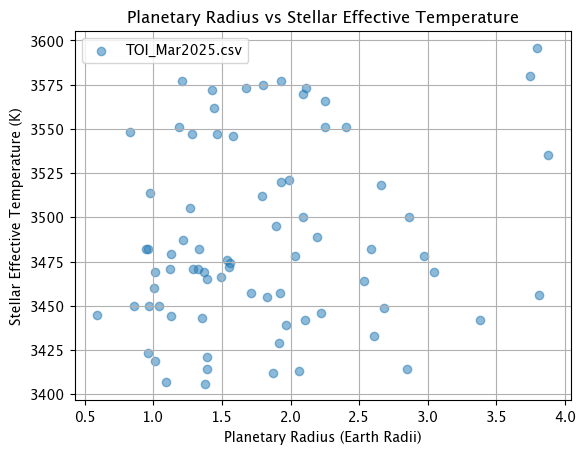

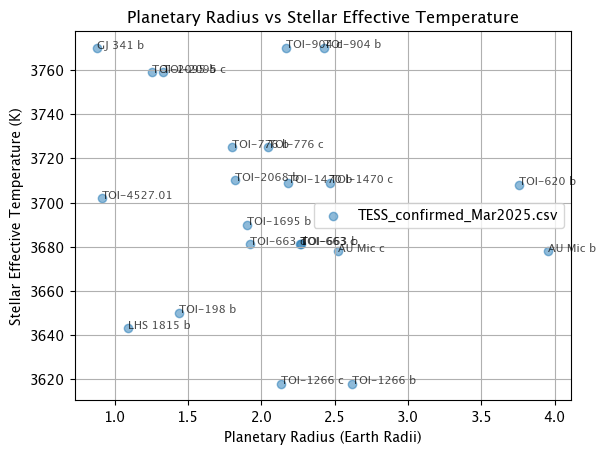

File 1: TOI_Mar2025.csv
76 planets, Teff 3400 - 3600 K

File 2: TESS_confirmed_Mar2025.csv:
22 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.26674641148325356, P-value: 0.14346895361121437
KS Statistic for 'st_teff': 1.0, P-value: 4.440892098500626e-16


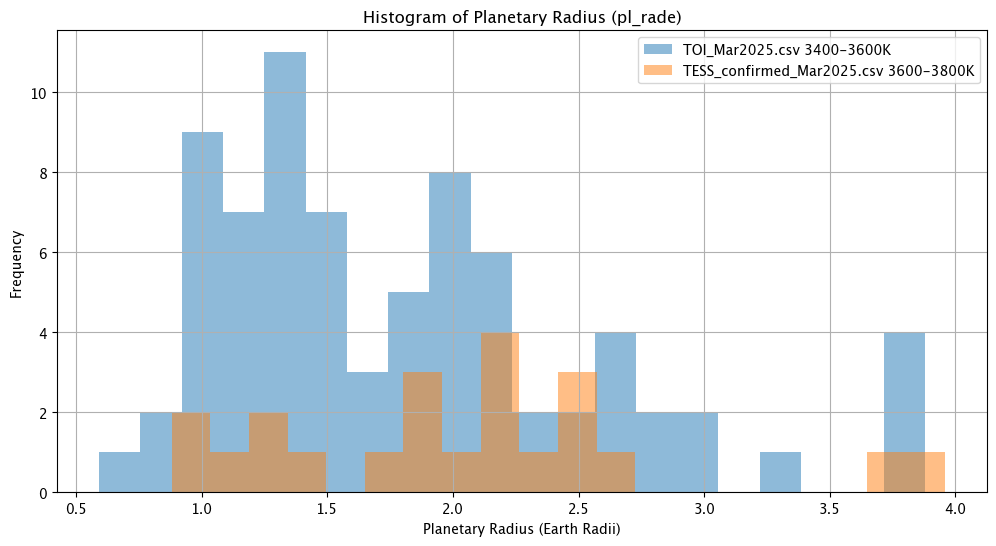

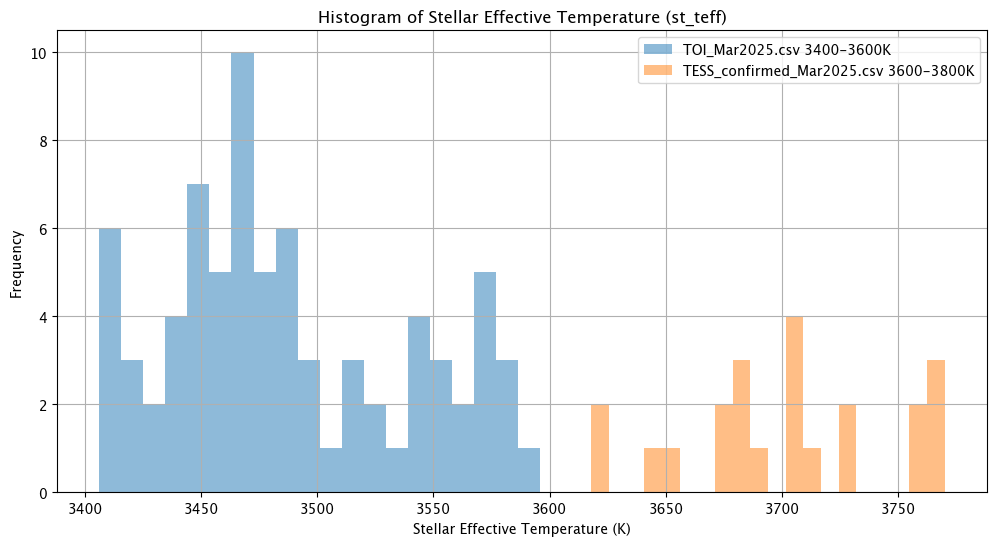

KeyError: 'pl_name'


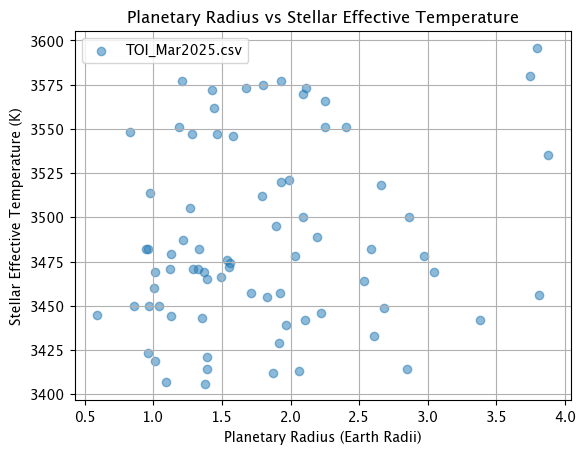

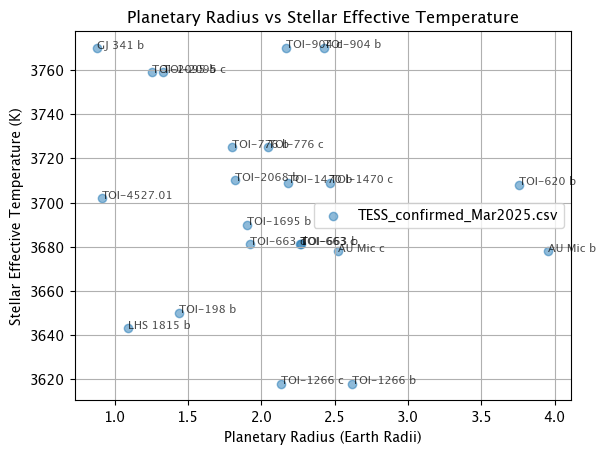

File 1: TOI_Mar2025.csv
76 planets, Teff 3400 - 3600 K

File 2: TESS_confirmed_Mar2025.csv:
22 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.26674641148325356, P-value: 0.14346895361121437
KS Statistic for 'st_teff': 1.0, P-value: 4.440892098500626e-16


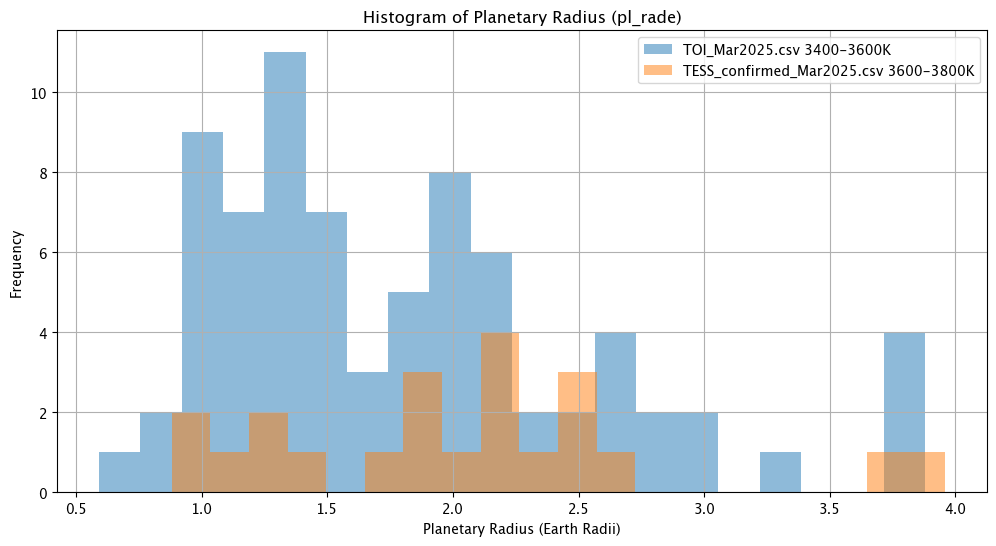

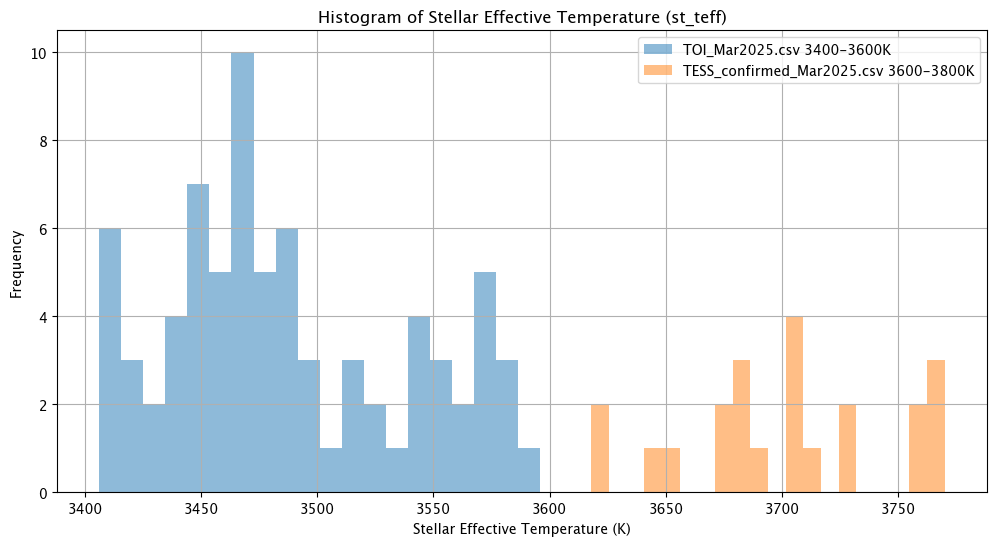

KeyError: 'pl_name'


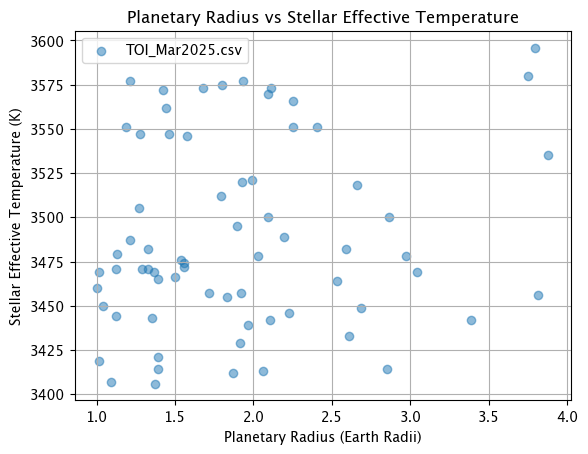

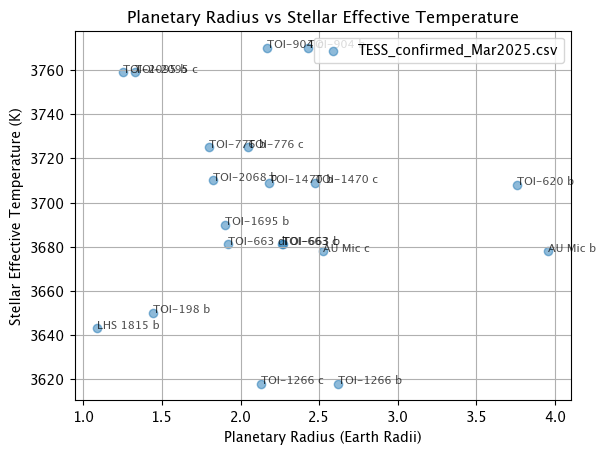

File 1: TOI_Mar2025.csv
68 planets, Teff 3400 - 3600 K

File 2: TESS_confirmed_Mar2025.csv:
20 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.2852941176470588, P-value: 0.13131240331400496
KS Statistic for 'st_teff': 1.0, P-value: 0.0


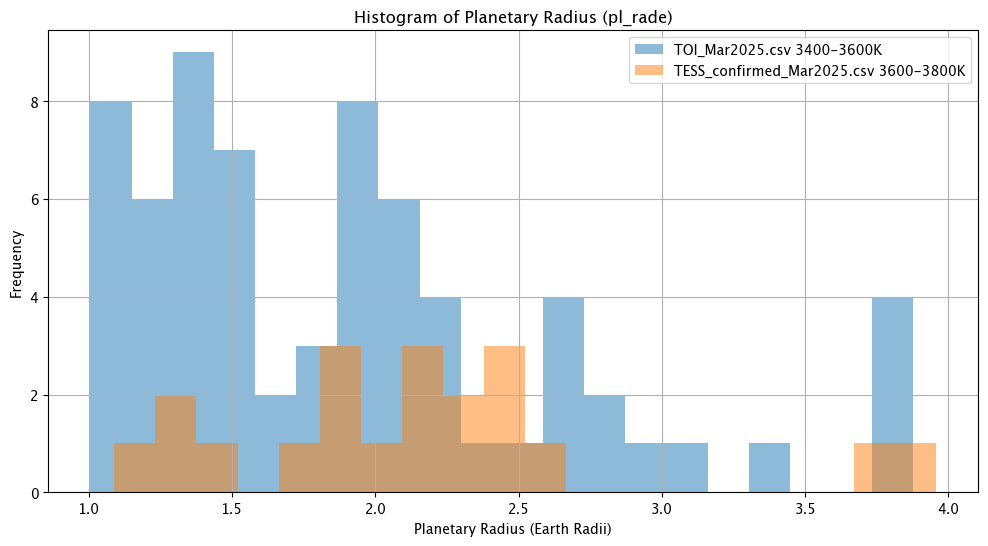

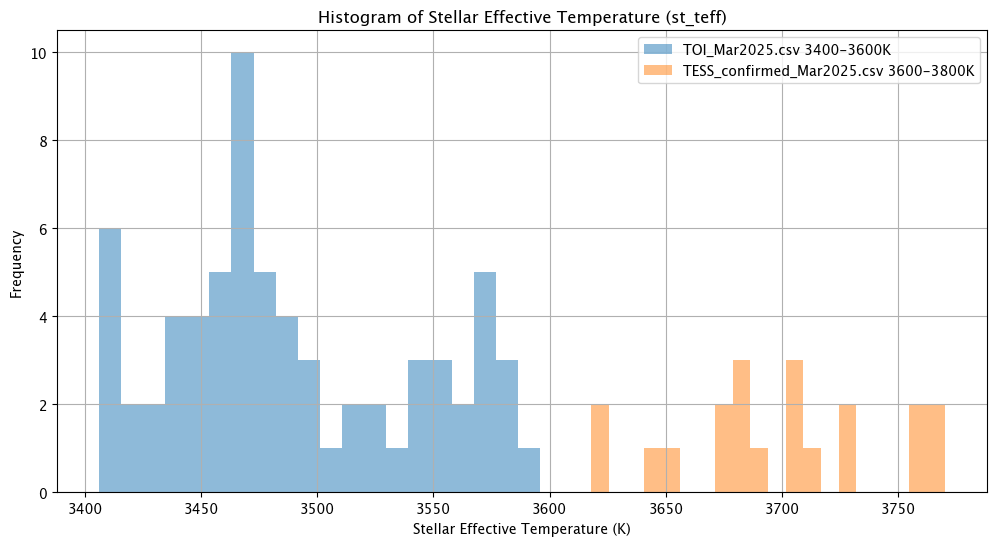

KeyError: 'pl_name'


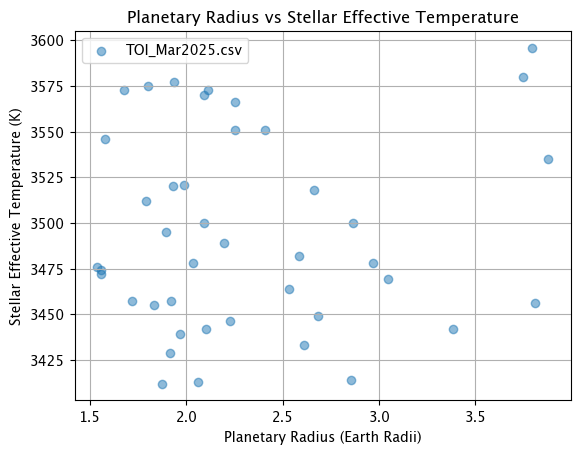

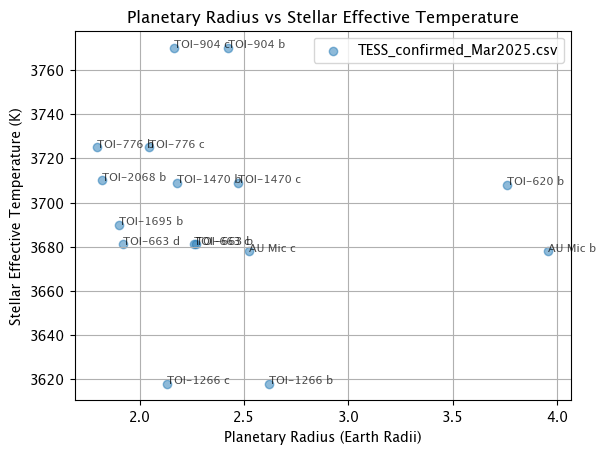

File 1: TOI_Mar2025.csv
42 planets, Teff 3400 - 3600 K

File 2: TESS_confirmed_Mar2025.csv:
16 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.23511904761904762, P-value: 0.4637302088473
KS Statistic for 'st_teff': 1.0, P-value: 2.5091040356528538e-14


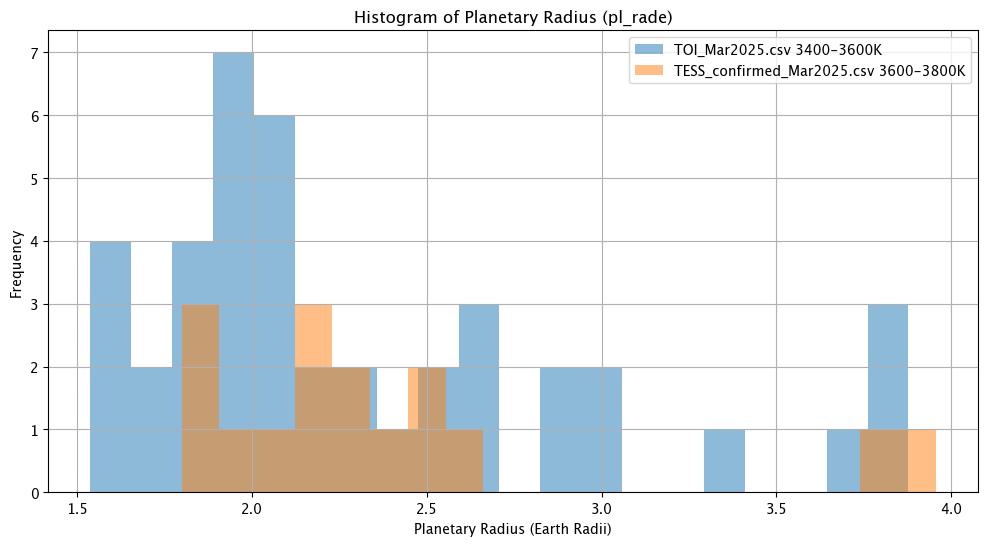

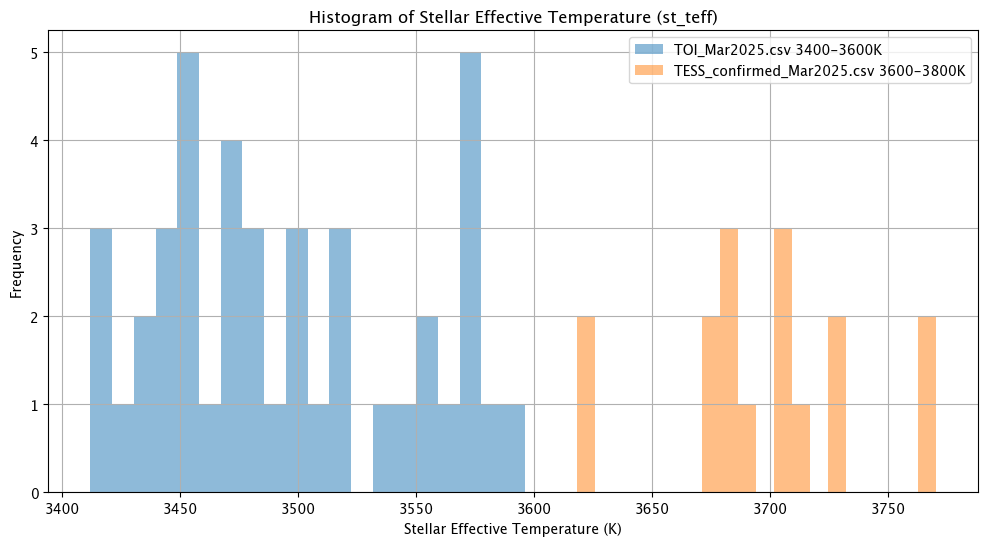

KeyError: 'pl_name'


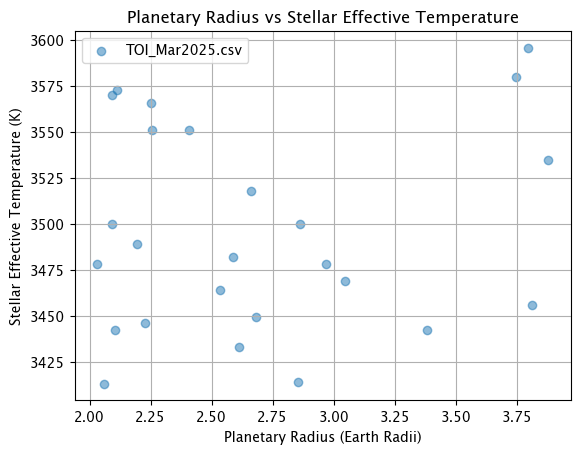

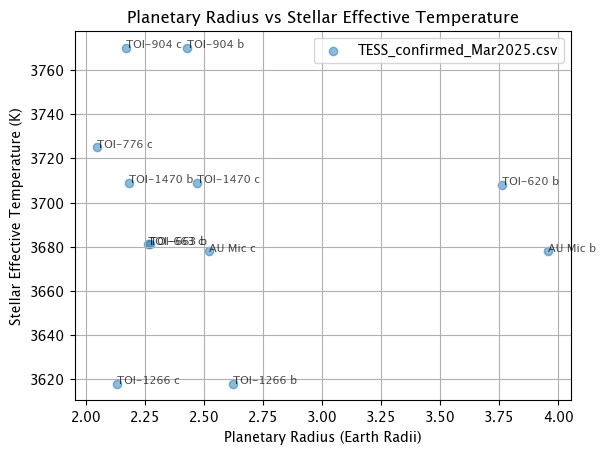

File 1: TOI_Mar2025.csv
25 planets, Teff 3400 - 3600 K

File 2: TESS_confirmed_Mar2025.csv:
12 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.31, P-value: 0.33256451871906945
KS Statistic for 'st_teff': 1.0, P-value: 1.07963171736003e-09


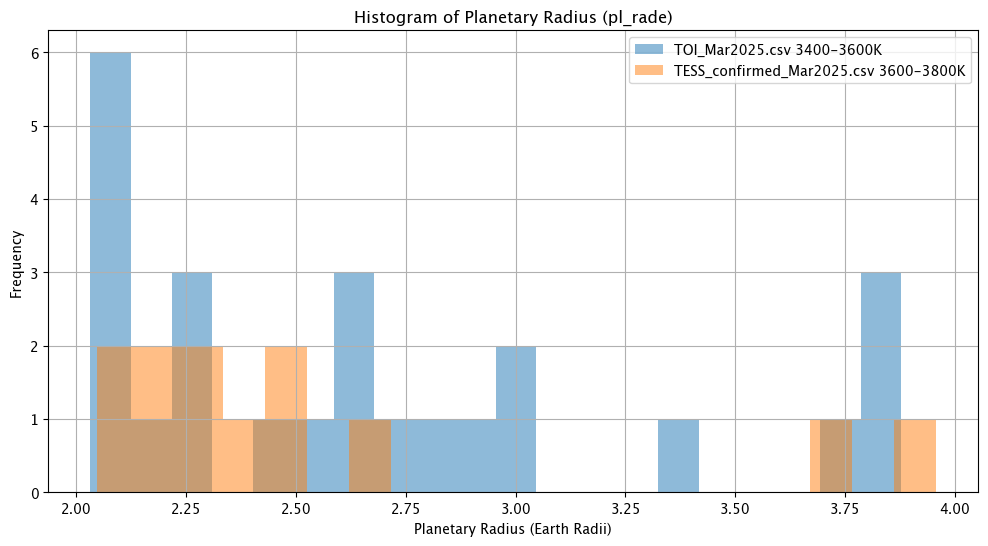

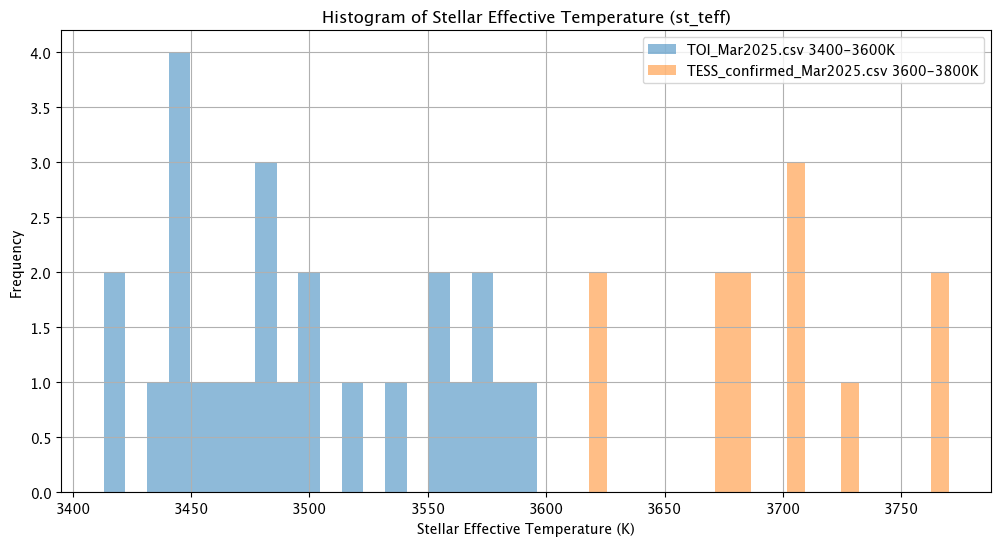

KeyError: 'pl_name'


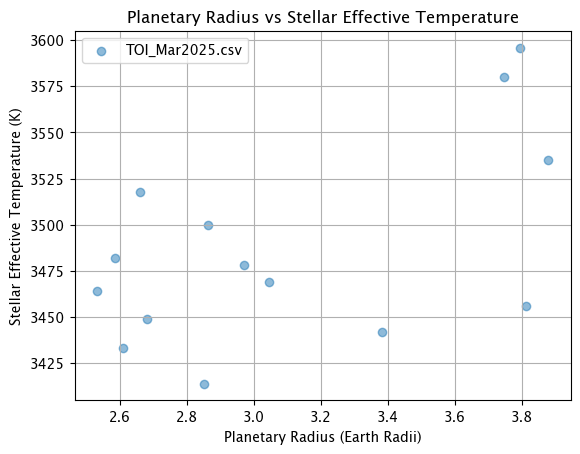

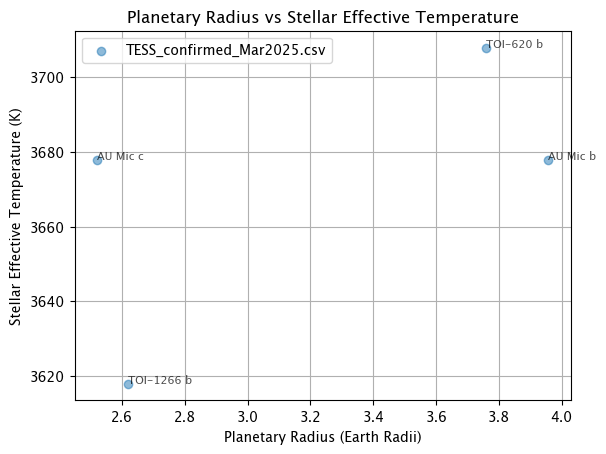

File 1: TOI_Mar2025.csv
14 planets, Teff 3400 - 3600 K

File 2: TESS_confirmed_Mar2025.csv:
4 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.2857142857142857, P-value: 0.9163398692810457
KS Statistic for 'st_teff': 1.0, P-value: 0.0006535947712418277


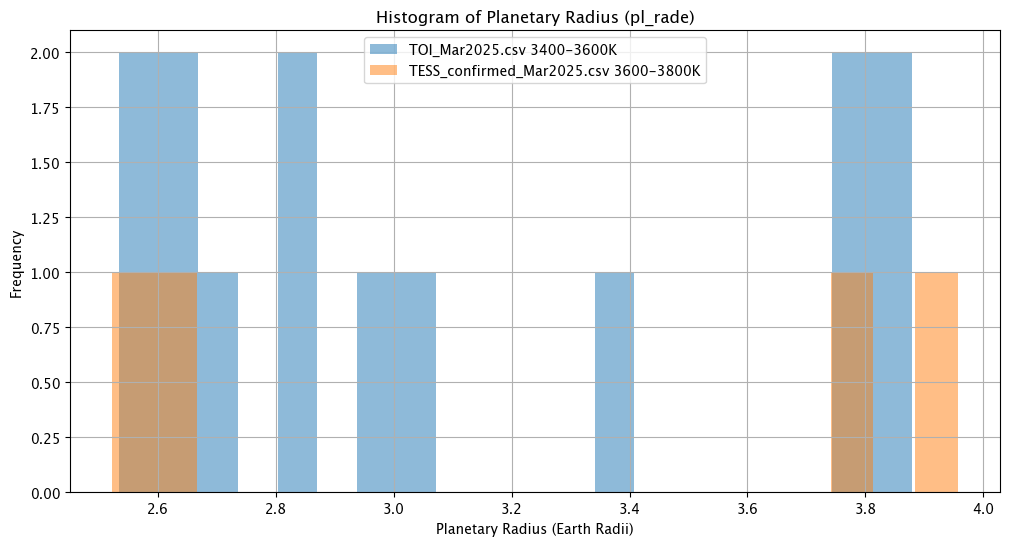

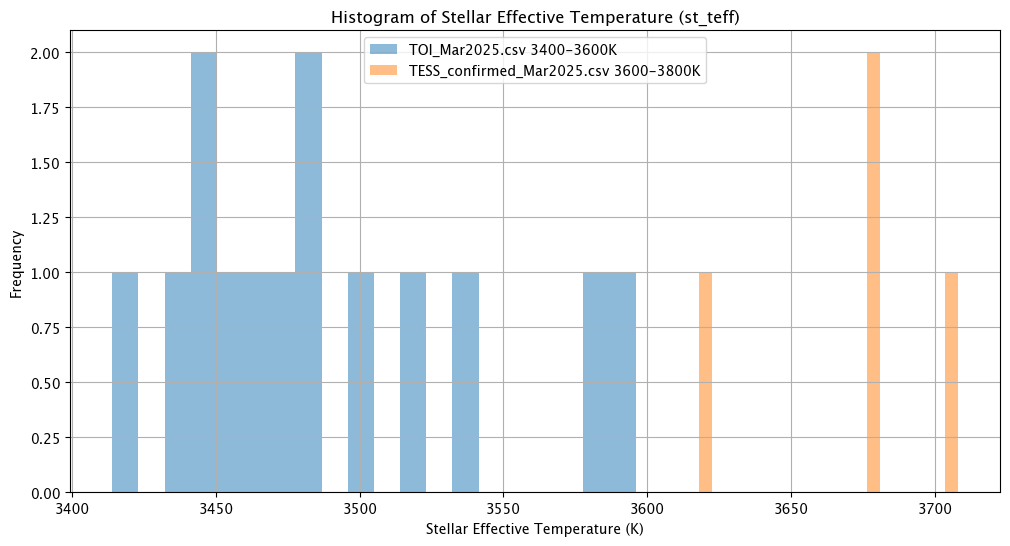

KeyError: 'pl_name'


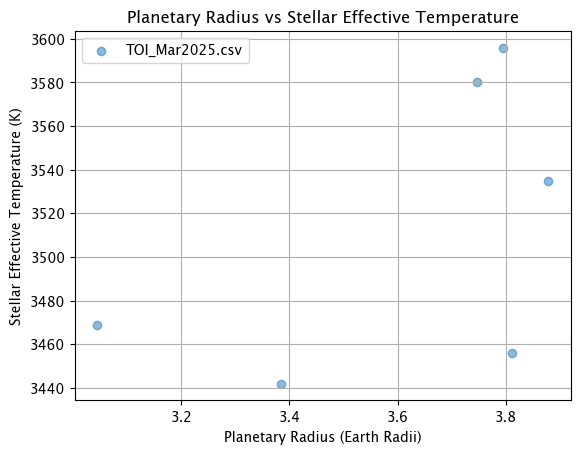

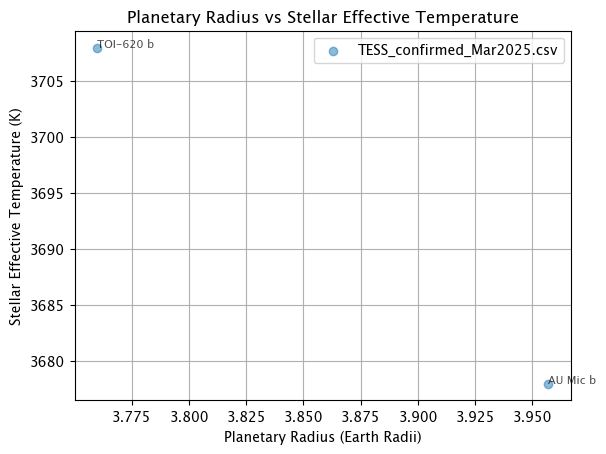

File 1: TOI_Mar2025.csv
6 planets, Teff 3400 - 3600 K

File 2: TESS_confirmed_Mar2025.csv:
2 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.5, P-value: 0.8571428571428572
KS Statistic for 'st_teff': 1.0, P-value: 0.0714285714285714


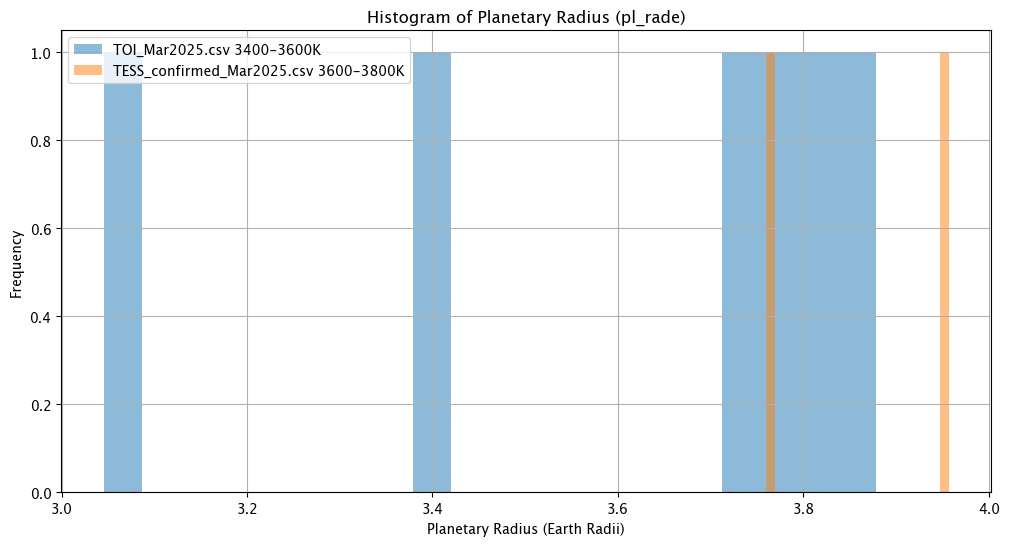

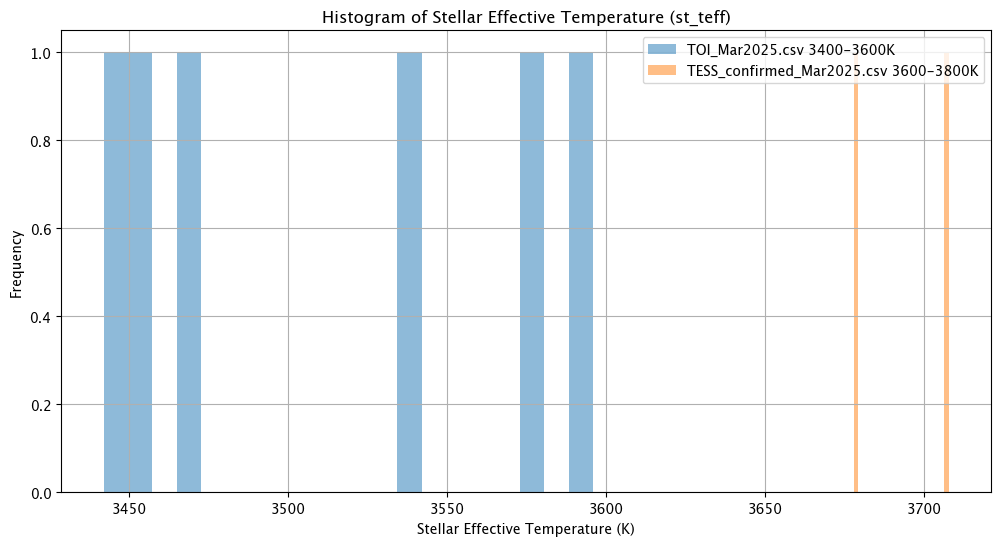

KeyError: 'pl_name'


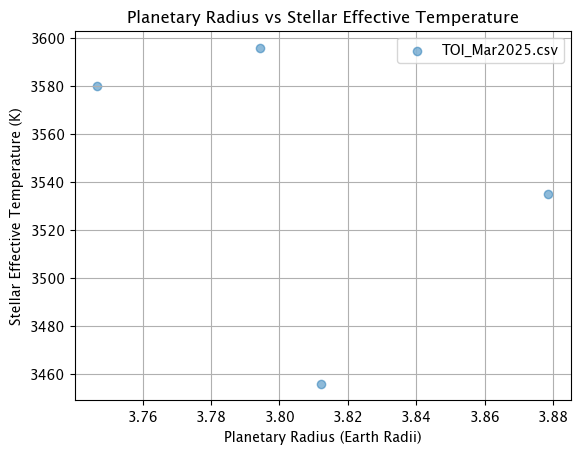

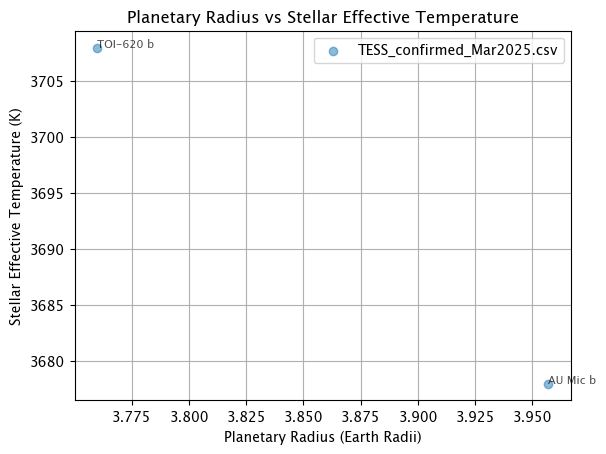

File 1: TOI_Mar2025.csv
4 planets, Teff 3400 - 3600 K

File 2: TESS_confirmed_Mar2025.csv:
2 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.5, P-value: 0.9333333333333333
KS Statistic for 'st_teff': 1.0, P-value: 0.1333333333333333


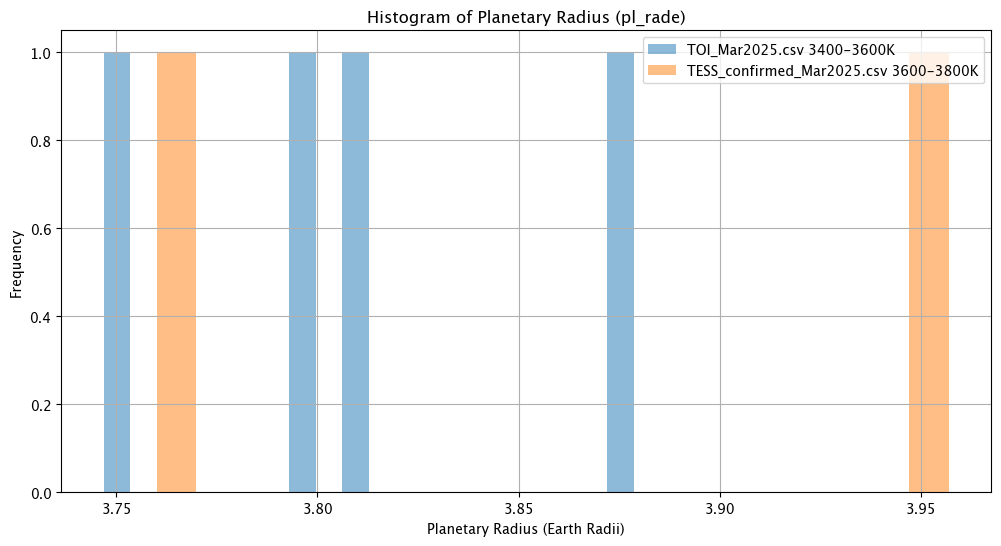

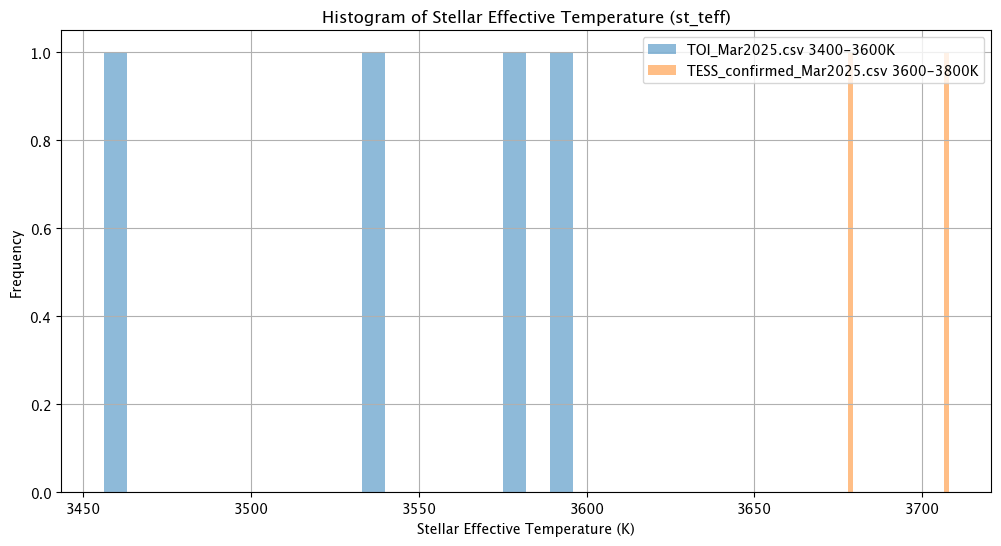

In [32]:
###CELL TO RUN KS TESTS
teff_min1 = 3400
teff_max1 = 3600
teff_min2 = 3600
teff_max2 = 3800

rad_max1 = 4
rad_max2 = 4

results_df = pd.DataFrame()

#LOOP
for rad_min in np.arange(0, 4, 0.5):
    rad_min1 = rad_min
    rad_min2 = rad_min
    results_df = perform_and_save_ks_test(teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2)

# #SINGULAR
#results_df = perform_and_save_ks_test(teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2)


Effective Temperature and Planetary Radius Ranges:
Teff Min1: [3000]
Teff Max1: [3200]
Teff Min2: [3200]
Teff Max2: [3400]
Rad Min1: [0.  0.5 1.  1.5 2.  2.5 3. ]
Rad Max1: [4]
Rad Min2: [0.  0.5 1.  1.5 2.  2.5 3. ]
Rad Max2: [4]


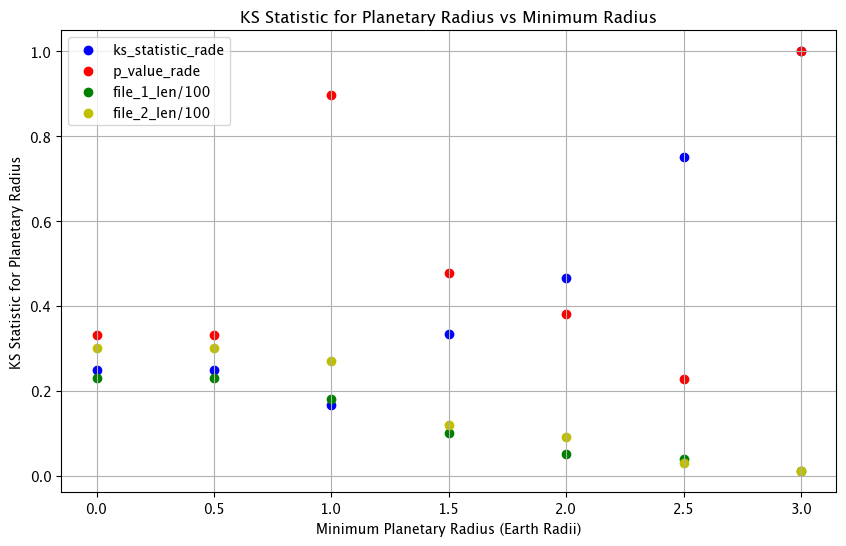

KeyError: 'pl_name'


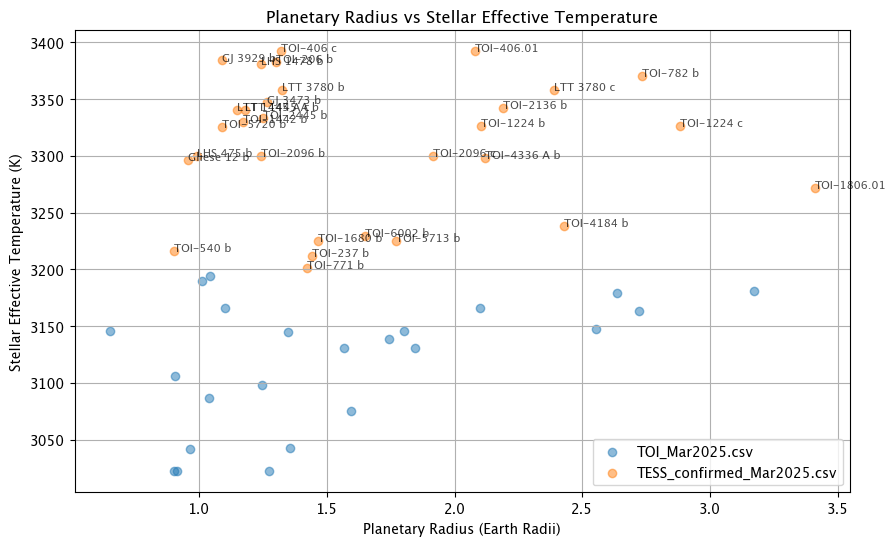

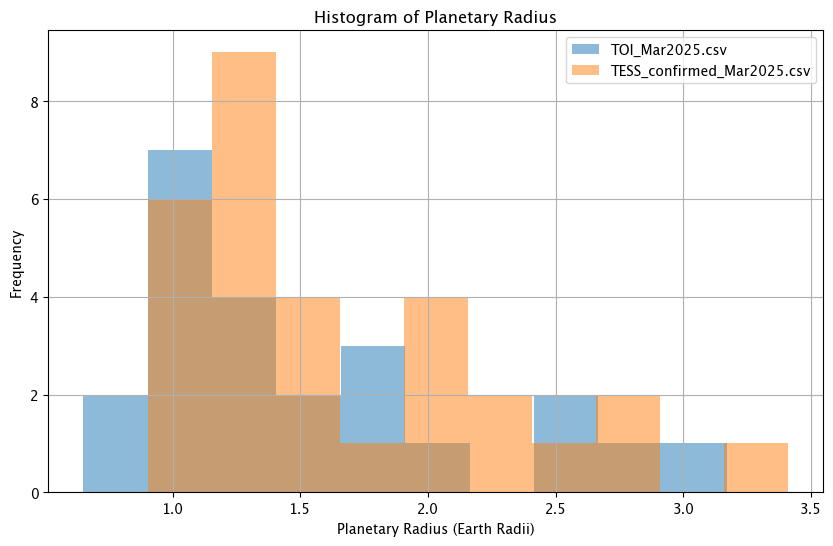

In [31]:
teff_min1_range = (3000, 3001)
teff_max1_range = (3200, 3201)
teff_min2_range = (3200, 3201)
teff_max2_range = (3400, 3401)
rad_min1_range = (0, 4)
rad_max1_range = (4, 4.1)
rad_min2_range = (0, 4)
rad_max2_range = (4, 4.1)

sample_results_df = filter_and_plot_results(results_df, teff_min1_range, teff_max1_range, teff_min2_range, teff_max2_range, rad_min1_range, rad_max1_range, rad_min2_range, rad_max2_range)

teff_min1 = teff_min1_range[0]
teff_max1 = teff_max1_range[0]
teff_min2 = teff_min2_range[0]
teff_max2 = teff_max2_range[0]
rad_min1 = rad_min1_range[0]
rad_max1 = rad_max1_range[0]
rad_min2 = rad_min2_range[0]
rad_max2 = rad_max2_range[0]

histogram('TOI_Mar2025.csv', 71, 'TESS_confirmed_Mar2025.csv', 104, teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2)


#at 2min planetary radius, the samples are most different, they are most similar without doing any radius cuts


#hihg p value - sample is so small you can't tell the difference OR samples are very similar


Effective Temperature and Planetary Radius Ranges:
Teff Min1: [3200]
Teff Max1: [3400]
Teff Min2: [3400]
Teff Max2: [3600]
Rad Min1: [0.  0.5 1.  1.5 2.  2.5 3.  3.5]
Rad Max1: [4]
Rad Min2: [0.  0.5 1.  1.5 2.  2.5 3.  3.5]
Rad Max2: [4]


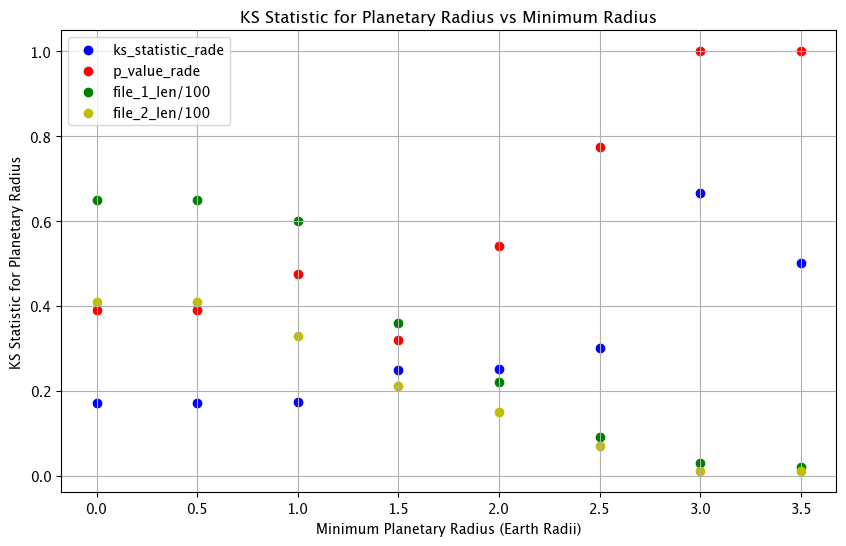

KeyError: 'pl_name'


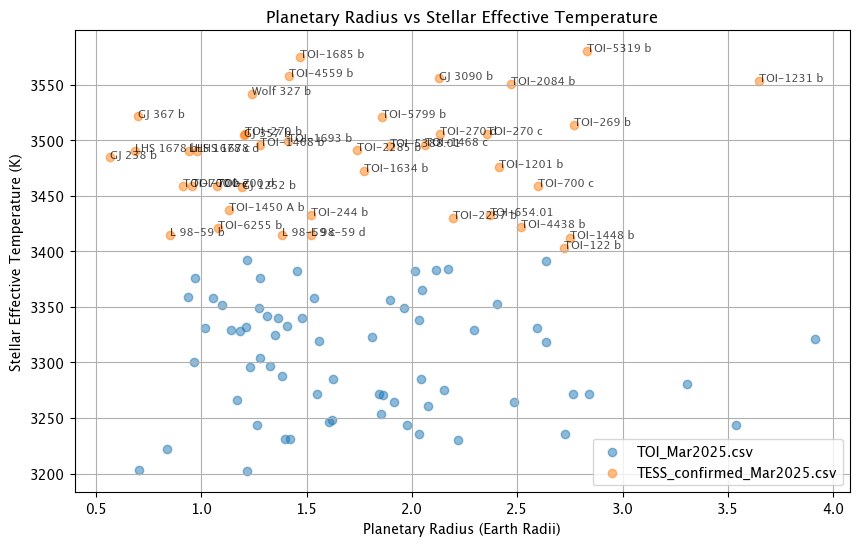

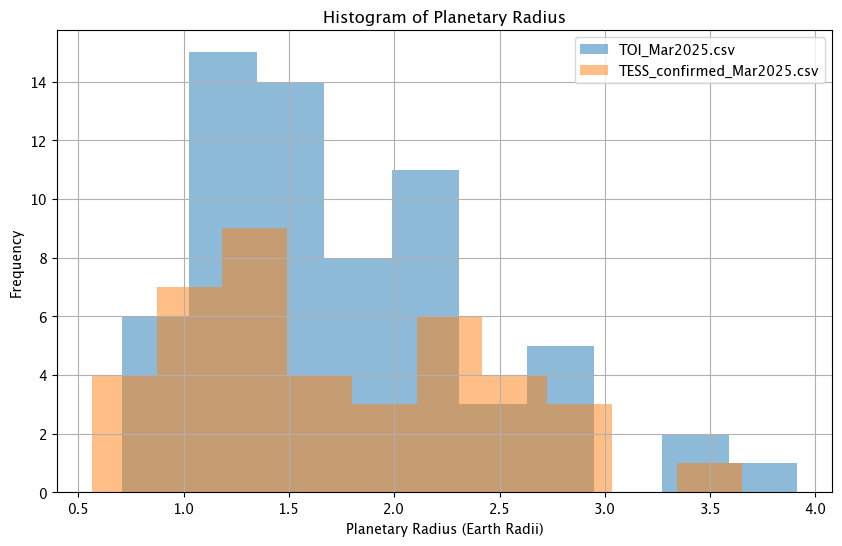

In [28]:
#print(results_df)
# Define the ranges for effective temperature and planetary radius
teff_min1_range = (3200, 3201)
teff_max1_range = (3400, 3401)
teff_min2_range = (3400, 3401)
teff_max2_range = (3600, 3601)
rad_min1_range = (0, 4)
rad_max1_range = (4, 4.1)
rad_min2_range = (0, 4)
rad_max2_range = (4, 4.1)


sample_results_df = filter_and_plot_results(results_df, teff_min1_range, teff_max1_range, teff_min2_range, teff_max2_range, rad_min1_range, rad_max1_range, rad_min2_range, rad_max2_range)

teff_min1 = teff_min1_range[0]
teff_max1 = teff_max1_range[0]
teff_min2 = teff_min2_range[0]
teff_max2 = teff_max2_range[0]
rad_min1 = rad_min1_range[0]
rad_max1 = rad_max1_range[0]
rad_min2 = rad_min2_range[0]
rad_max2 = rad_max2_range[0]

histogram('TOI_Mar2025.csv', 71, 'TESS_confirmed_Mar2025.csv', 104, teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2)

#between these teff bins, the samples are most similar at minimum radius of 1, and it gets worse as you cut off more planets, but not linearly

#! could be more giant planets so that when we remove the small ones they are more similar


Effective Temperature and Planetary Radius Ranges:
Teff Min1: [3400]
Teff Max1: [3600]
Teff Min2: [3600]
Teff Max2: [3800]
Rad Min1: [0.  0.5 1.  1.5 2.  2.5 3.  3.5]
Rad Max1: [4]
Rad Min2: [0.  0.5 1.  1.5 2.  2.5 3.  3.5]
Rad Max2: [4]


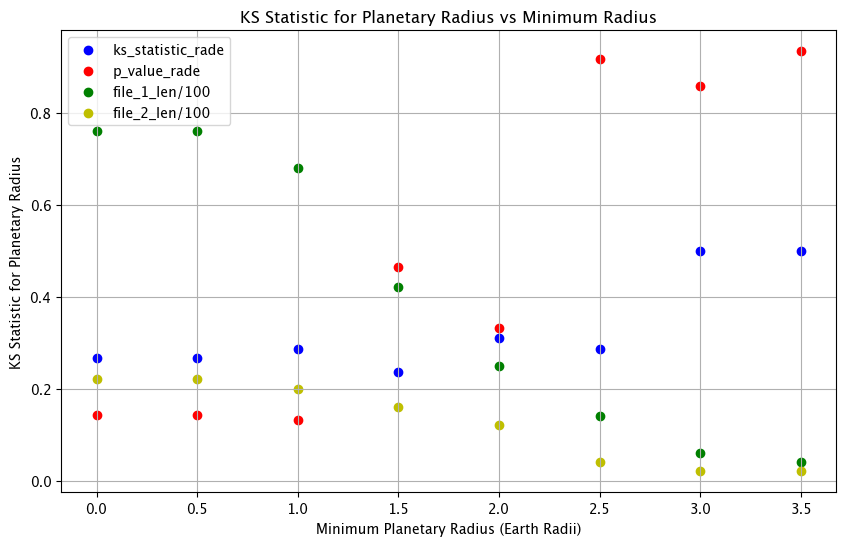

KeyError: 'pl_name'


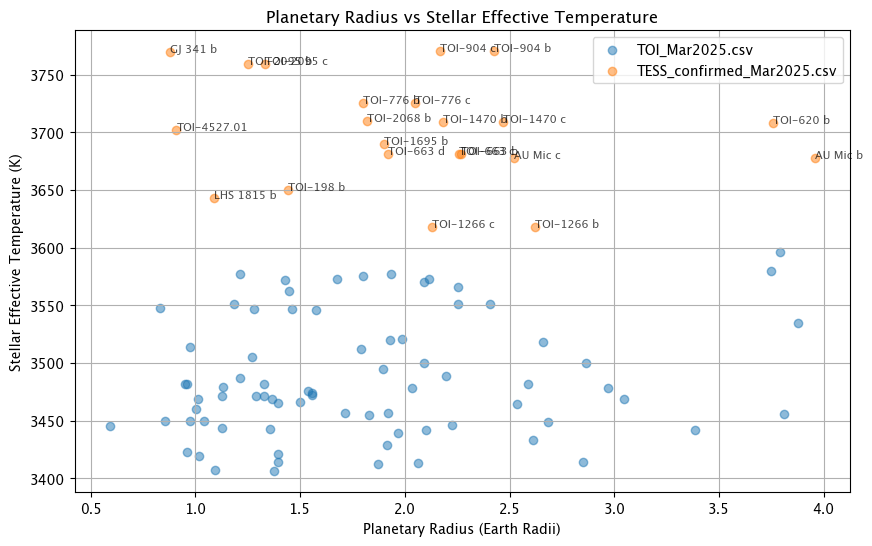

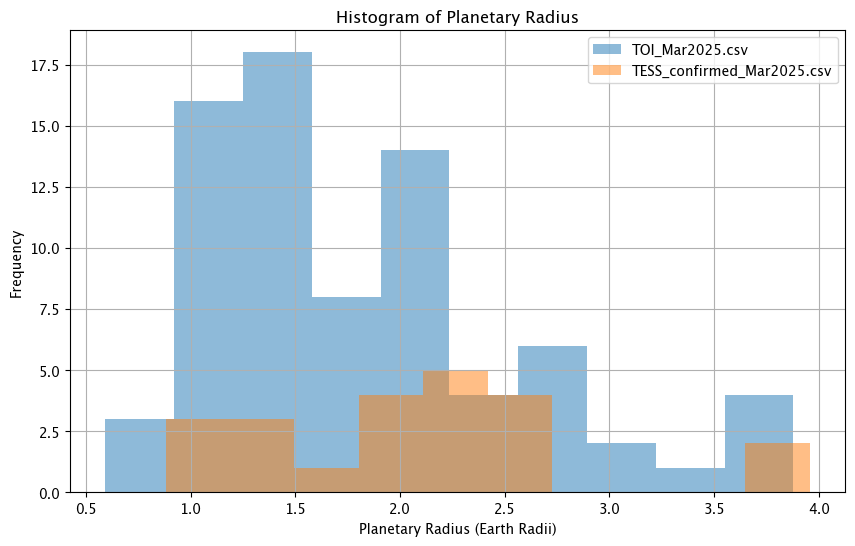

In [33]:
#print(results_df)
# Define the ranges for effective temperature and planetary radius
teff_min1_range = (3400, 3401)
teff_max1_range = (3600, 3601)
teff_min2_range = (3600, 3601)
teff_max2_range = (3800, 3801)
rad_min1_range = (0, 4)
rad_max1_range = (4, 4.1)
rad_min2_range = (0, 4)
rad_max2_range = (4, 4.1)

sample_results_df = filter_and_plot_results(results_df, teff_min1_range, teff_max1_range, teff_min2_range, teff_max2_range, rad_min1_range, rad_max1_range, rad_min2_range, rad_max2_range)

teff_min1 = teff_min1_range[0]
teff_max1 = teff_max1_range[0]
teff_min2 = teff_min2_range[0]
teff_max2 = teff_max2_range[0]
rad_min1 = rad_min1_range[0]
rad_max1 = rad_max1_range[0]
rad_min2 = rad_min2_range[0]
rad_max2 = rad_max2_range[0]

histogram('TOI_Mar2025.csv', 71, 'TESS_confirmed_Mar2025.csv', 104, teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2)

#the sample are most different at minimum radius of 1.75 or 2.5, but are remakably similar at 2-2.25?? Why does it behave this way? There must be some planet sizes in this specific range that are shared between samples

#!look what the statistic implies in the actual data, have a lower upper limit (6earth radii)